# voxel-wise plotting for 3D volumes

in this tutorial, you will see how to use `yabplot` to visualize continuous 3D volumes. Unlike surface-based plotting, voxel-wise plotting renders the internal structure of the data using nested isosurfaces.

### inputs and outputs

**we start with:**
1.  **data volume (`.nii.gz`):** the 3D NIfTI file where each voxel contains continuous scalar data (e.g., an fMRI task activation map, t-statistics, or p-values).

In [1]:
import pooch
import yabplot as yab
import numpy as np 

## 1. basic voxel-wise plotting

the simplest way to plot is to pass the path to the NIfTI file. By default, `yabplot` will extract the top 5% of voxels and render them as nested shells.

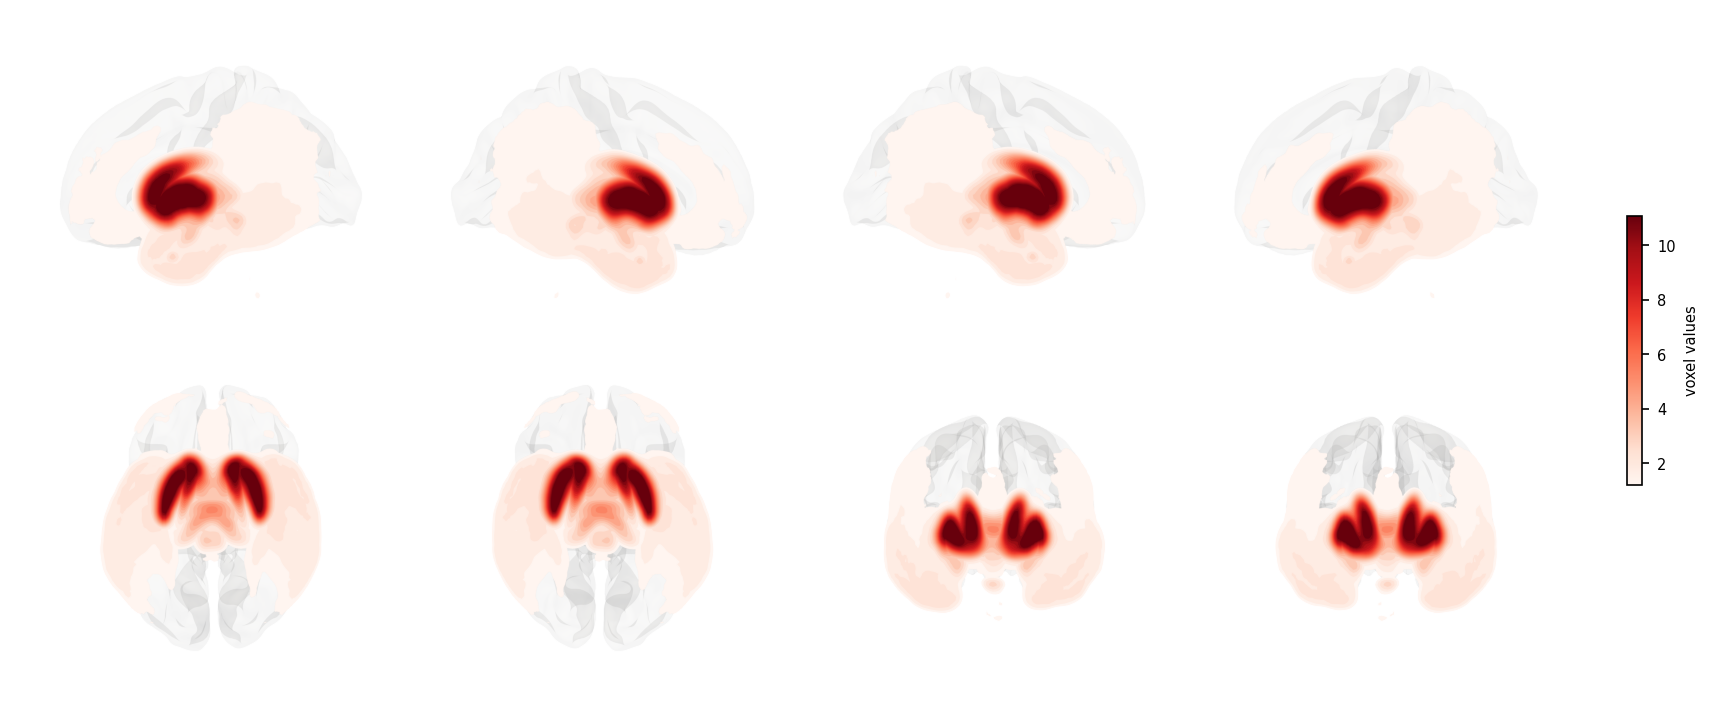

In [6]:
# fetch an example 3D PET volume (D2 receptor density)
# [1] Hansen et al., Nat Neurosci (2022)
nii_url = "https://github.com/netneurolab/hansen_receptors/raw/main/data/PET_nifti_images/D2_flb457_hc55_sandiego.nii.gz"
nii_path = pooch.retrieve(url=nii_url, known_hash=None, path=pooch.os_cache("yabplot"), 
                          fname="sandiego2015_pet.nii.gz")

# standard visualization using the 'Reds' colormap
ax = yab.plot_voxelwise(nii_path, cmap='Reds')

## 2. controlling the threshold

you can control which voxels are visible using the `threshold` parameter. This accepts either a direct numeric value or a percentile string (e.g., `'99%'` to see only the highest intensity peaks).

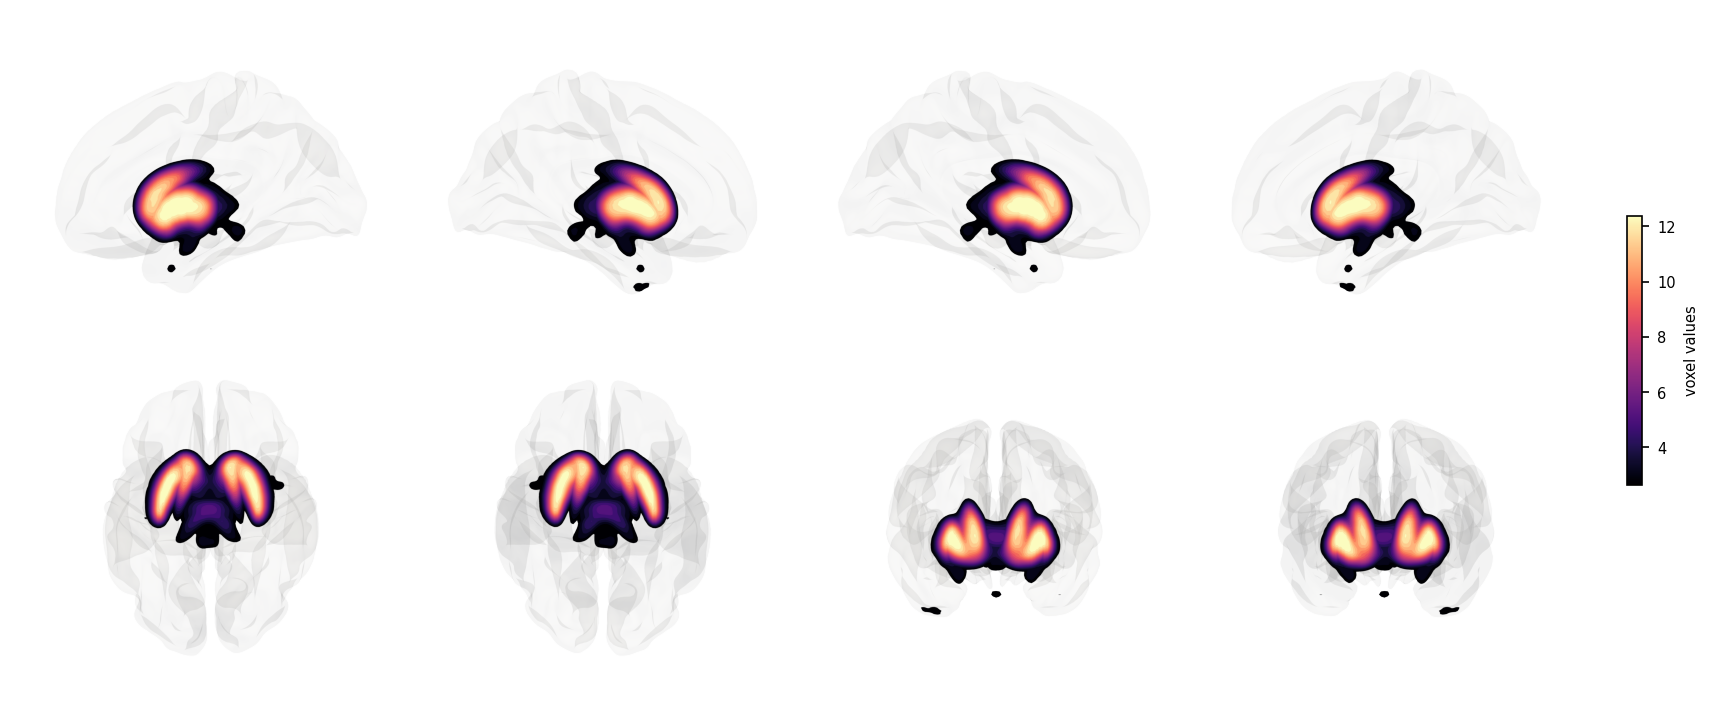

In [7]:
# show only the top 1% of highest intensity voxels
ax = yab.plot_voxelwise(nii_path, threshold='99%', cmap='magma')

## 3. refining the isosurfaces

you can adjust how many "layers" are shown and how smooth they appear. 
- `n_levels`: higher values create a smoother transition between intensity levels.
- `blur_sigma`: applies a slight Gaussian blur to the data before extracting shells, which helps remove voxel "jaggedness" in noisy data (but be careful in using this to not distort the true findings!).

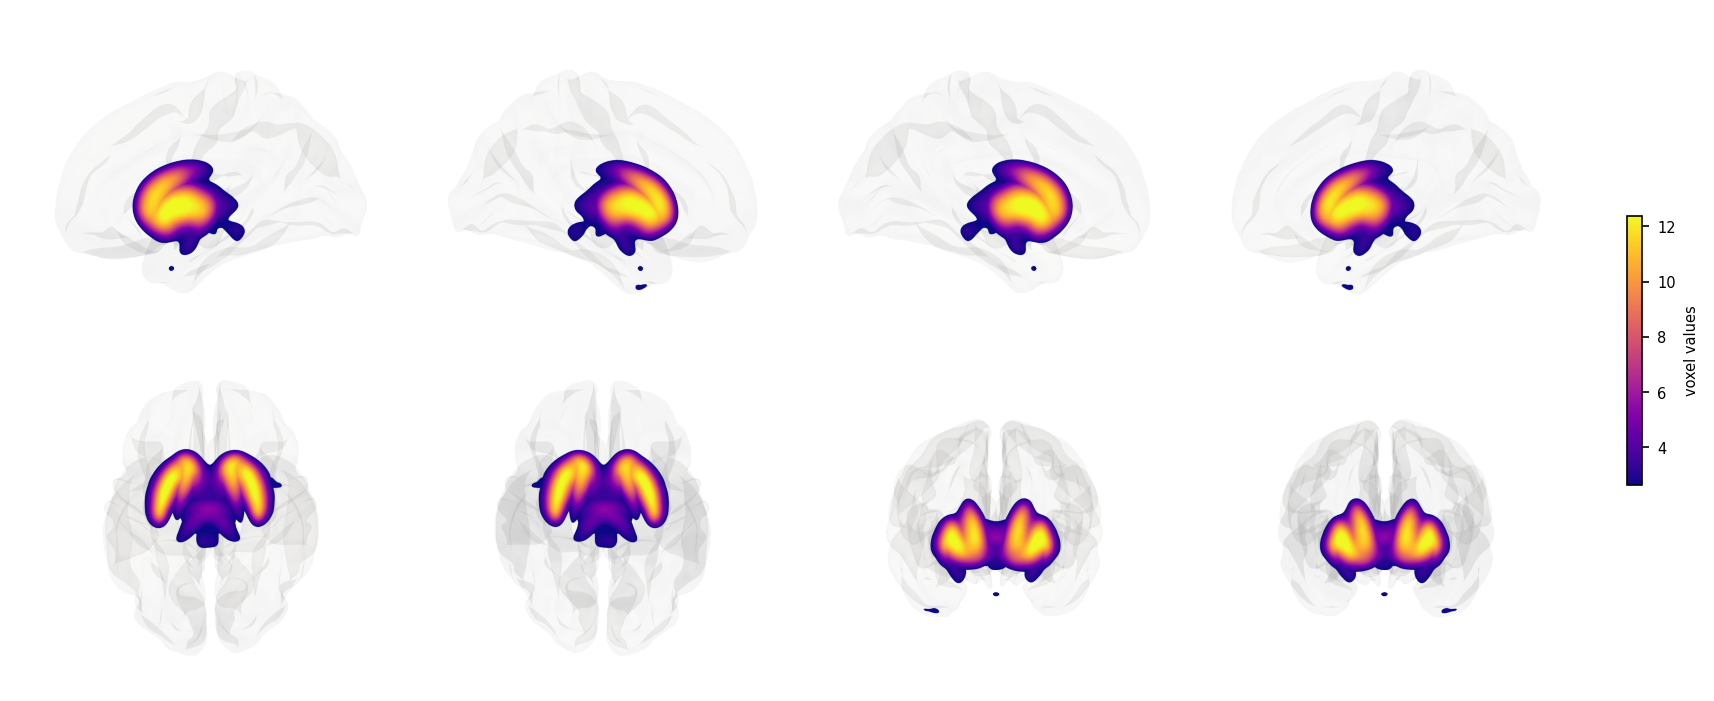

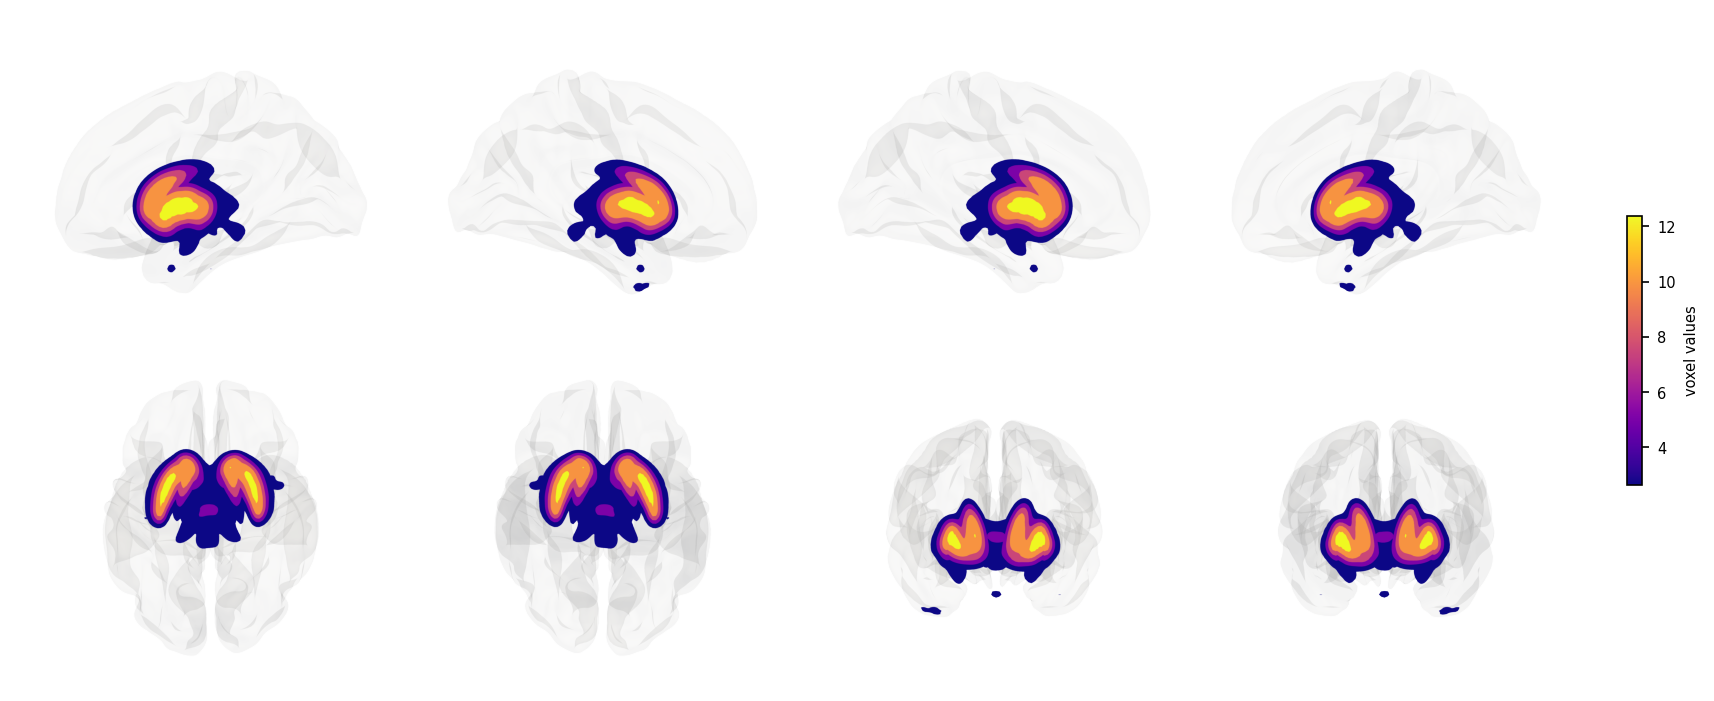

In [9]:
ax = yab.plot_voxelwise(
    nii_path, 
    n_levels=50,       # more detailed shells
    blur_sigma=1.0,    # smooth out voxel edges
    cmap='plasma',
    threshold='99%'
)

ax = yab.plot_voxelwise(
    nii_path, 
    n_levels=5,        # less detailed shells (more cartoony)
    blur_sigma=0.0,    # no smoothing (default)
    cmap='plasma',
    threshold='99%'
)

## 4. changing how the nifti is displayed with context brain mesh

by default, the voxel data is rendered inside a light-gray brain mesh, which you can modify as with most plotting functions. however, the parameter `ignore_bmesh` is specifc to plot_voxelwise and is True by default, indicating that the image you are visualising is plotted "after" the context brain (but still inside of context brain). see the difference below.

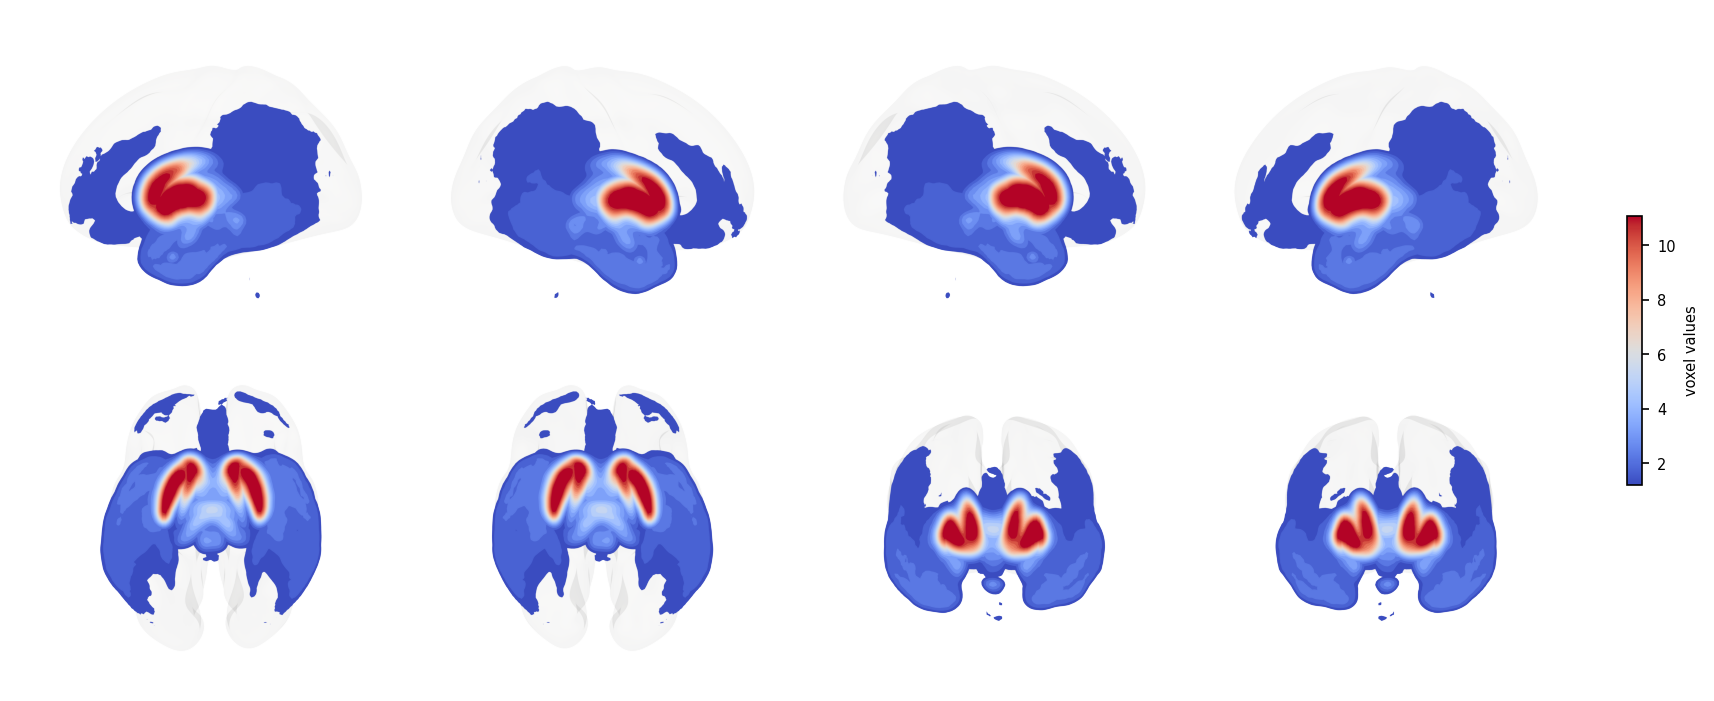

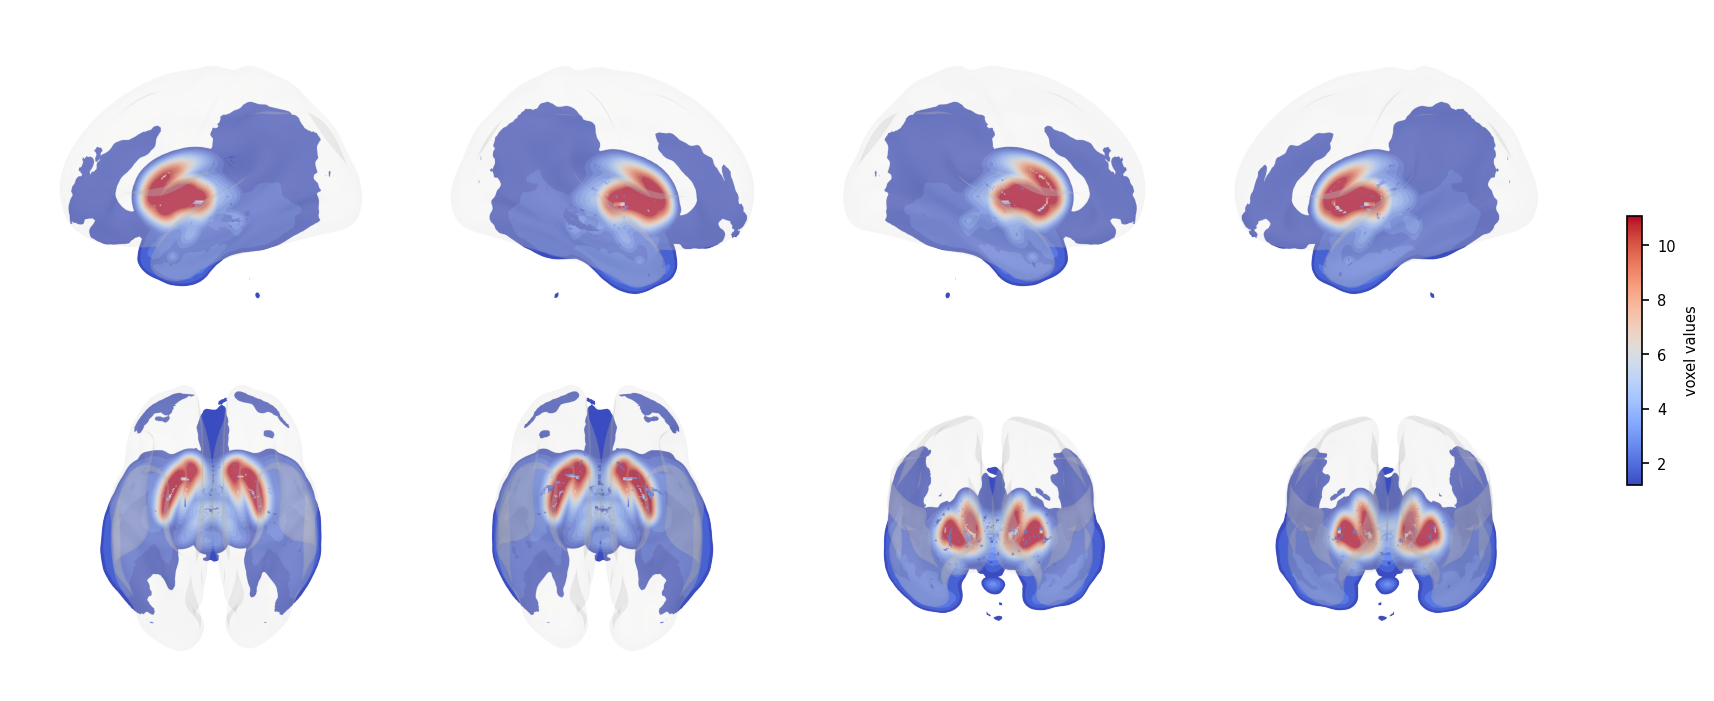

In [10]:
ax = yab.plot_voxelwise(
    nii_path, 
    bmesh='inflated',      # use an inflated brain for context
    ignore_bmesh=True     # dont let the brain surface "hide" the image data
)
ax = yab.plot_voxelwise(
    nii_path, 
    bmesh='inflated',      # use an inflated brain for context
    ignore_bmesh=False     # let the brain surface obscure internal data
)